# DATA DOWNLOAD AND PLOT
We use 2025 data to decide on a monthly investement.

/tmp/ipykernel_5872/2503600738.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  msft = yf.download("MSFT", start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_5872/2503600738.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download("AAPL", start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


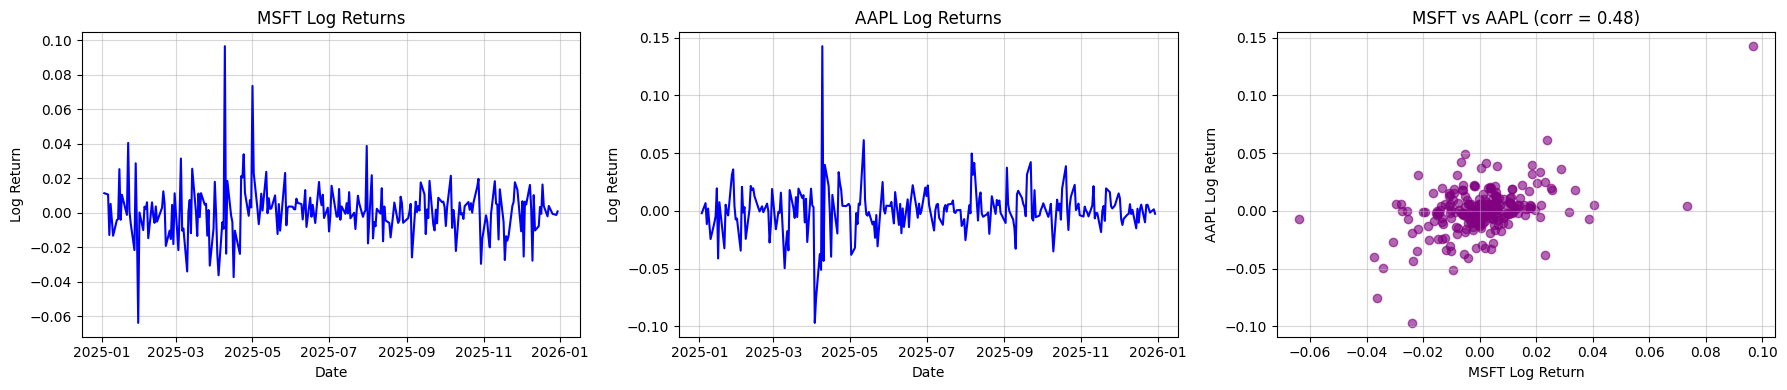

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Download data
# -----------------------------
start_date = "2025-01-01"
end_date = "2025-12-31"

msft = yf.download("MSFT", start=start_date, end=end_date)
aapl = yf.download("AAPL", start=start_date, end=end_date)

# -----------------------------
# 2. Compute log-returns
# -----------------------------
msft["LogReturn"] = np.log(msft["Close"] / msft["Close"].shift(1))
aapl["LogReturn"] = np.log(aapl["Close"] / aapl["Close"].shift(1))

msft = msft.dropna()
aapl = aapl.dropna()

# -----------------------------
# 3. Align dates (IMPORTANT)
# -----------------------------
data = pd.DataFrame({
    "MSFT": msft["LogReturn"],
    "AAPL": aapl["LogReturn"]
}).dropna()

# -----------------------------
# 4. Compute correlation
# -----------------------------
rho = data["MSFT"].corr(data["AAPL"])

# -----------------------------
# 5. Plot: one row, three panels
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# --- MSFT time series ---
axes[0].plot(data.index, data["MSFT"], color="blue")
axes[0].set_title("MSFT Log Returns")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Log Return")
axes[0].grid(True, alpha=0.5)

# --- AAPL time series ---
axes[1].plot(data.index, data["AAPL"], color="blue")
axes[1].set_title("AAPL Log Returns")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Log Return")
axes[1].grid(True, alpha=0.5)

# --- Scatterplot ---
axes[2].scatter(data["MSFT"], data["AAPL"], color="purple", alpha=0.6)
axes[2].set_title(f"MSFT vs AAPL (corr = {rho:.2f})")
axes[2].set_xlabel("MSFT Log Return")
axes[2].set_ylabel("AAPL Log Return")
axes[2].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

# COMPUTING REQUIRED SUMMARIES
We use the simple historical approach to estimate expected log-returns and their variability. We also transform them to a 21-day scale which is the one assumed for our investment.

In [2]:

# Compute daily mean, variance, and correlation
mean_msft_daily = msft["LogReturn"].mean()
var_msft_daily = msft["LogReturn"].var()
std_msft_daily = msft["LogReturn"].std()

mean_aapl_daily = aapl["LogReturn"].mean()
var_aapl_daily = aapl["LogReturn"].var()
std_aapl_daily = aapl["LogReturn"].std()

corr_msft_aapl = msft["LogReturn"].corr(aapl["LogReturn"])

# Convert to monthly values (21 days)
mean_msft_monthly = mean_msft_daily * 21
var_msft_monthly = var_msft_daily * 21
std_msft_monthly = std_msft_daily * np.sqrt(21)

mean_aapl_monthly = mean_aapl_daily * 21
var_aapl_monthly = var_aapl_daily * 21
std_aapl_monthly = std_aapl_daily * np.sqrt(21)

cov_msft_aapl_monthly = corr_msft_aapl * std_msft_monthly * std_aapl_monthly

# -----------------------------
# Print daily estimates
# -----------------------------
print("===== Daily Estimates =====")
print(f"Apple - Mean: {mean_aapl_daily:.6f}, Variance: {var_aapl_daily:.6f}, Std Dev: {std_aapl_daily:.6f}")
print(f"Microsoft - Mean: {mean_msft_daily:.6f}, Variance: {var_msft_daily:.6f}, Std Dev: {std_msft_daily:.6f}")
print(f"Correlation: {corr_msft_aapl:.6f}")

# -----------------------------
# Print monthly estimates
# -----------------------------
print("\n===== Monthly Estimates =====")
print(f"Apple - Mean: {mean_aapl_monthly:.6f}, Variance: {var_aapl_monthly:.6f}, Std Dev: {std_aapl_monthly:.6f}")
print(f"Microsft - Mean: {mean_msft_monthly:.6f}, Variance: {var_msft_monthly:.6f}, Std Dev: {std_msft_monthly:.6f}")
print(f"Correlation: {corr_msft_aapl:.6f}, Covariance: {cov_msft_aapl_monthly:.6f}")

===== Daily Estimates =====
Apple - Mean: 0.000475, Variance: 0.000412, Std Dev: 0.020300
Microsoft - Mean: 0.000644, Variance: 0.000231, Std Dev: 0.015184
Correlation: 0.477183

===== Monthly Estimates =====
Apple - Mean: 0.009969, Variance: 0.008654, Std Dev: 0.093024
Microsft - Mean: 0.013526, Variance: 0.004842, Std Dev: 0.069581
Correlation: 0.477183, Covariance: 0.003089


# IDENTIFYING THE MINIMUM VARIANCE PORTFOLIO

In [3]:
# Compute minimum variance portfolio weights
w_A_min_var = (var_msft_monthly - cov_msft_aapl_monthly) / (
    var_aapl_monthly + var_msft_monthly - 2 * cov_msft_aapl_monthly
)
w_B_min_var = 1 - w_A_min_var

# Compute expected return and variance of the minimum variance portfolio
expected_return_min_var = w_A_min_var * mean_aapl_monthly + w_B_min_var * mean_msft_monthly
min_var_value = (
    w_A_min_var**2 * var_aapl_monthly
    + w_B_min_var**2 * var_msft_monthly
    + 2 * w_A_min_var * w_B_min_var * cov_msft_aapl_monthly
)

print("===== Minimum Variance Portfolio =====")
print(f"Optimal w_A (Apple): {w_A_min_var:.6f}")
print(f"Optimal w_B (Microsoft): {w_B_min_var:.6f}")
print(f"Expected Return: {expected_return_min_var:.6f}")
print(f"Variance: {min_var_value:.6f}")
print(f"Standard Deviation: {np.sqrt(min_var_value):.6f}")


===== Minimum Variance Portfolio =====
Optimal w_A (Apple): 0.239540
Optimal w_B (Microsoft): 0.760460
Expected Return: 0.012674
Variance: 0.004422
Standard Deviation: 0.066496


# CREATING THE PORTFOLIO AND EFFICIENT FRONTIER

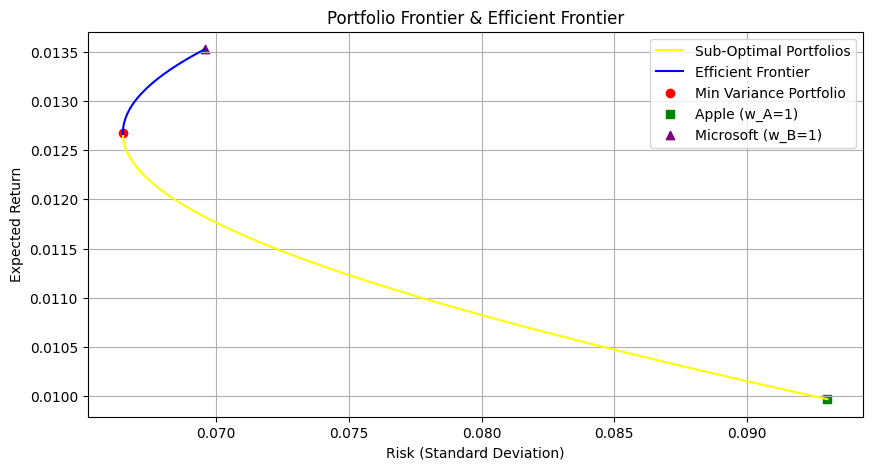

In [6]:
# Generate portfolios for plotting
w_A_range = np.linspace(0, 1, 100)
expected_returns = w_A_range * mean_aapl_monthly + (1 - w_A_range) * mean_msft_monthly
variances = (
    w_A_range**2 * var_aapl_monthly
    + (1 - w_A_range)**2 * var_msft_monthly
    + 2 * w_A_range * (1 - w_A_range) * cov_msft_aapl_monthly
)
std_devs = np.sqrt(variances)

# Plot the efficient frontier
plt.figure(figsize=(10, 5))
min_var_index = np.argmin(std_devs)

plt.plot(std_devs[min_var_index:], expected_returns[min_var_index:], color="yellow", label="Sub-Optimal Portfolios")
plt.plot(std_devs[:min_var_index+1], expected_returns[:min_var_index+1], color="blue", label="Efficient Frontier")
plt.scatter(
    np.sqrt(min_var_value), expected_return_min_var, color="red", marker="o", label="Min Variance Portfolio"
)
plt.scatter(std_aapl_monthly, mean_aapl_monthly, color="green", marker="s", label="Apple (w_A=1)")
plt.scatter(std_msft_monthly, mean_msft_monthly, color="purple", marker="^", label="Microsoft (w_B=1)")

plt.xlabel("Risk (Standard Deviation)")
plt.ylabel("Expected Return")
plt.title("Portfolio Frontier & Efficient Frontier")
plt.legend()
plt.grid(True)
plt.show()
